In [1]:
# I added this cell
# ! pip install torchtext==0.6.0 --user
base_file_name       = "Transformer-124"
train_file_name      = base_file_name+"-train.csv"
test_file_name       = base_file_name+"-test.csv"
validation_file_name = base_file_name+"-validation.csv"
model_file_name      = base_file_name+"-model.pt"

batch_size_start = 32 #32  # original_value = 64
pos_weight = .5 # the value of pos_weight to resolve impalancing  original_value = .29
# learning rate 
lr_v = 0.00007 # 1e-4 , 0.00007, 1e-5, 0.00005
n_epoch_number = 10
DROPOUT = 0.6 # 0.5 , 0.45
# reduced_dimensions = 768
random_s = 3


In [2]:
import torch

import pandas as pd
from torchtext.data import Field, BucketIterator, TabularDataset,LabelField
from sklearn.model_selection import train_test_split
import random
import numpy as np
from transformers import BertTokenizer
import torch.nn.functional as F

from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import cohen_kappa_score

import re
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import WordPunctTokenizer
from nltk.tokenize import TweetTokenizer
from nltk.tokenize import LegalitySyllableTokenizer
from nltk import word_tokenize
import contractions
from nltk.corpus import words
from torchtext import data
LP = LegalitySyllableTokenizer(words.words())

from transformers import BertTokenizer, BertModel
# from transformers import BertTokenizer, BertModel

from transformers import BertTokenizer, BertModel
# from transformers import BertTokenizer, BertModel
from transformers import XLMRobertaTokenizer, XLMRobertaForSequenceClassification
from transformers import AutoTokenizer, AutoModel
from torch.utils.data import DataLoader

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
analyzer = SentimentIntensityAnalyzer()
from textblob import TextBlob

In [3]:

SEED = 1234

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [4]:
# tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
# # tokenizer = BertTokenizer.from_pretrained('bert-large-uncased')
# len(tokenizer.vocab)

BERT_MODEL = "roberta-base"
tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
len(tokenizer.vocab)

50265

In [5]:
init_token = tokenizer.cls_token
eos_token = tokenizer.sep_token
pad_token = tokenizer.pad_token
unk_token = tokenizer.unk_token

print(init_token, eos_token, pad_token, unk_token)

<s> </s> <pad> <unk>


In [6]:
init_token_idx = tokenizer.convert_tokens_to_ids(init_token)
eos_token_idx = tokenizer.convert_tokens_to_ids(eos_token)
pad_token_idx = tokenizer.convert_tokens_to_ids(pad_token)
unk_token_idx = tokenizer.convert_tokens_to_ids(unk_token)

print(init_token_idx, eos_token_idx, pad_token_idx, unk_token_idx)

0 2 1 3


In [7]:
init_token_idx = tokenizer.cls_token_id
eos_token_idx = tokenizer.sep_token_id
pad_token_idx = tokenizer.pad_token_id
unk_token_idx = tokenizer.unk_token_id

print(init_token_idx, eos_token_idx, pad_token_idx, unk_token_idx)

0 2 1 3


In [8]:
# max_input_length = tokenizer.max_model_input_sizes['bert-base-uncased']
# # max_input_length = tokenizer.max_model_input_sizes['bert-large-uncased']
# print(max_input_length)

max_input_length = tokenizer.max_model_input_sizes[BERT_MODEL]
print(max_input_length)

512


In [9]:
def tokenize_and_cut(sentence):
    tokens = tokenizer.tokenize(sentence) 
    tokens = tokens[:max_input_length-2]
    return tokens

In [10]:
from torchtext import data

Text = data.Field(batch_first = True,
                  use_vocab = False,
                  tokenize = tokenize_and_cut,
                  preprocessing = tokenizer.convert_tokens_to_ids,
                  init_token = init_token_idx,
                  eos_token = eos_token_idx,
                  pad_token = pad_token_idx,
                  unk_token = unk_token_idx,
                  include_lengths = True)

Urgency = LabelField(sequential=False, use_vocab=False,dtype = torch.float)
fields = {"Text": ("t", Text), "Urgency": ("ur", Urgency)}

In [11]:
def sentimentAnalysis (document):
    
    vs = analyzer.polarity_scores(document)
#     res = TextBlob(document)
#     document = str(res)+ " " + document 
# #     document = str(vs['neg'])+ " " + str(vs['pos'])+ " " +str(vs['compound'])+ " " + document 
    if vs['compound'] >= 0.05:
        document = "0 " + document # "positive " + document
    elif vs['compound'] <= -0.05:
        document = "1 " + document # "negative " + document
    else:
        document = "1 " + document  #  "natural " + document

    return document

In [12]:
def preprocess (document):
#     urgentList = ["?", "do no understand", "have to", "could you please", "certificate", "i have no idea", "these problems", 
#              "i am still waiting", "i'm not confused", "i didn't understand", "same issue", "doesn't match",
#              "challenge", "concern", "however", "not clear", "would like", "can we get", "may i make", "couldn't find"
#             , "i was sad", "access the videos", "how do you", "but i cannot", "i don't see", "can't find", "how do you suggest"
#              , "tech team", "instructor", "assignment", "how long", "assessments", " l have the same", "progress was not funtioning"
            
#                  ]
    
#     document = document.lower()
#     for simpol in urgentList:
#         if simpol in document:
#             document = "question " + document # document = "question " + document
#             break
#     if "question " not in document:
#         document = "answer " + document

        
#     if "?" in document:
#         document = "1 " + document
#     else:
#         document = "0 " + document
    if "?" in document:
        document = "question " + document # document = "question " + document
    else:
        document = "answer " + document

    return document

In [13]:
# GROUP A
# df =  pd.read_excel('D:\\ahmedFarouk\\MstanfordMOOCForumPostsSet.xlsx') #'mystanfordMOOCForumPostsSet.xlsx'
df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
df["Text"] = df["Text"].astype(str)
df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str) 
df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str) 
# df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# df["Text"] = df["Text"].apply(preprocess)
df["Text"] = df["Text"].apply(sentimentAnalysis)
df = df.loc[:, ['Text', 'Urgency']]
df.loc[df['Urgency']<4, ['Urgency']]=0
df.loc[df['Urgency']>=4, ['Urgency']]=1
print ('size of all data = ', df.shape)
train, test = train_test_split(df, test_size=0.2,stratify=df['Urgency'], random_state = random_s)
test,valid = train_test_split(test, test_size=0.5,stratify=test['Urgency'],random_state = random_s)
print ('size of all data = ', test.shape,valid.shape,train.shape)

train.to_csv("cnnTrain.csv", index=False)
valid.to_csv("cnnValid.csv", index=False)
test.to_csv("cnnTest.csv", index=False)
# df.to_csv("total.csv", index=False)

size of all data =  (29597, 2)
size of all data =  (2960, 2) (2960, 2) (23677, 2)


In [14]:
# # Group B
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str)
# # df["Text"] = df["Text"].astype(str)
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str)
# # df['Text']=df['Text'].apply(preprocess)  
# df["course_display_name"].unique()
# print(df.shape) 
# df1_test = df.loc[(df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014') | 
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') ]

# df1_train = df.loc[(df["course_display_name"] != 'HumanitiesScience/StatLearning/Winter2014') & 
#        (df["course_display_name"] != 'Medicine/HRP258/Statistics_in_Medicine') &
#        (df["course_display_name"] != 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') &
#        (df["course_display_name"] != 'Education/EDUC115N/How_to_Learn_Math')]

# df1_train = df1_train.loc[:, ['Text', 'Urgency']] 
# df1_train.loc[df1_train['Urgency']<4, ['Urgency']]=0
# df1_train.loc[df1_train['Urgency']>=4, ['Urgency']]=1

# df1_test = df1_test.loc[:, ['Text', 'Urgency']] 
# df1_test.loc[df1_test['Urgency']<4, ['Urgency']]=0
# df1_test.loc[df1_test['Urgency']>=4, ['Urgency']]=1
# print('df1',df1_test.shape,df1_train.shape) 

# df2 =  df.loc[(df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]
# print(df2.shape)
# df2 = df2.loc[:, ['Text', 'Urgency']] 
# df2.loc[df2['Urgency']<4, ['Urgency']]=0
# df2.loc[df2['Urgency']>=4, ['Urgency']]=1

# df2_train, df2_test = train_test_split(df2, test_size=0.2,stratify=df2['Urgency'])


# train = pd.concat([df1_train, df2_train])
# test = pd.concat([df1_test, df2_test])
# test,valid = train_test_split(test, test_size=0.5,stratify=test['Urgency'])
# print('Final',train.shape,test.shape,valid.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [15]:
# # Group C
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["Text"].astype(str)
# # df["Text"] = df["Text"].apply(preprocess)
# # # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str) 
# # df["Text"] = df["Text"].astype(str) 
# # df['Text']=df['Text'] 

# df["Text"] = df["Text"].astype(str)
# df["Text"] = df["Text"].apply(preprocess)
# # df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str) 
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str) 
# # df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# # df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].apply(sentimentAnalysis)

# df["course_display_name"].unique()
# print(df.shape) 
# test = df.loc[(df["course_display_name"] == 'HumanitiesScience/Stats216/Winter2014') | 
#        (df["course_display_name"] == 'HumanitiesSciences/EP101/Environmental_Physiology') |
#        (df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014')| 
#        (df["course_display_name"] == 'HumanitiesSciences/Econ1V/Summer2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/Econ-1/Summer2014') |
#        (df["course_display_name"] ==  'GlobalHealth/WomensHealth/Winter2014')]
       

# train = df.loc[(df["course_display_name"] =='Medicine/SciWrite/Fall2013') | 
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') |
#        (df["course_display_name"] == 'Medicine/MedStats/Summer2014') |
#        (df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]

# train = train.loc[:, ['Text', 'Urgency']] 
# train.loc[train['Urgency']<4, ['Urgency']]=0
# train.loc[train['Urgency']>=4, ['Urgency']]=1

# test = test.loc[:, ['Text', 'Urgency']] 
# test.loc[test['Urgency']<4, ['Urgency']]=0
# test.loc[test['Urgency']>=4, ['Urgency']]=1
# test,valid = train_test_split(test, test_size=0.7,stratify=test['Urgency'])
# print(test.shape,valid.shape,train.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [16]:
# # Group C
# df =  pd.read_excel('mystanfordMOOCForumPostsSet.xlsx')
# # df["Text"] = df["Text"].astype(str)
# # df["Text"] = df["Text"].apply(preprocess)
# # # df["Text"] = df["CourseType"].astype(str) +" "+ df["Text"].astype(str) 
# # df["Text"] = df["Text"].astype(str) 
# # df['Text']=df['Text'] 

# df["Text"] = df["Text"].astype(str)
# df["Text"] = df["Text"].apply(preprocess)
# # df["Text"] = df["Text"].astype(str) #+" "+df["CourseType"].astype(str) #+df["post_type"].astype(str) 
# df["Text"] = df["CourseType"].astype(str)+" "+df["post_type"].astype(str)+" "+df["Text"].astype(str) 
# # df['Text']=df["course_display_name"].astype(str)+" "+df['Text']  # df["course_display_name"].astype(str)+" "+
# # df["Text"] = df["Text"].apply(preprocess)
# df["Text"] = df["Text"].apply(sentimentAnalysis)

# df["course_display_name"].unique()
# print(df.shape) 
# test = df.loc[(df["course_display_name"] == 'HumanitiesScience/Stats216/Winter2014') | 
#        (df["course_display_name"] == 'HumanitiesSciences/EP101/Environmental_Physiology') |
#        (df["course_display_name"] == 'HumanitiesScience/StatLearning/Winter2014')| 
#        (df["course_display_name"] == 'HumanitiesSciences/Econ1V/Summer2014') |
#        (df["course_display_name"] == 'HumanitiesSciences/Econ-1/Summer2014') |
#        (df["course_display_name"] ==  'GlobalHealth/WomensHealth/Winter2014')]
       

# train = df.loc[(df["course_display_name"] =='Medicine/SciWrite/Fall2013') | 
#        (df["course_display_name"] == 'Medicine/HRP258/Statistics_in_Medicine') |
#        (df["course_display_name"] == 'Medicine/SURG210/Managing_Emergencies_What_Every_Doctor_Must_Know') |
#        (df["course_display_name"] == 'Medicine/MedStats/Summer2014') |
#        (df["course_display_name"] == 'Education/EDUC115N/How_to_Learn_Math')]

# train = train.loc[:, ['Text', 'Urgency']] 
# train.loc[train['Urgency']<4, ['Urgency']]=0
# train.loc[train['Urgency']>=4, ['Urgency']]=1

# test = test.loc[:, ['Text', 'Urgency']] 
# test.loc[test['Urgency']<4, ['Urgency']]=0
# test.loc[test['Urgency']>=4, ['Urgency']]=1
# train,valid = train_test_split(train, test_size=0.1,stratify=train['Urgency'])
# print(test.shape,valid.shape,train.shape)

# train.to_csv("cnnTrain.csv", index=False)
# valid.to_csv("cnnValid.csv", index=False)
# test.to_csv("cnnTest.csv", index=False)

In [17]:
train_data, valid_data, test_data = TabularDataset.splits(path = "", #path = 'D:\\ahmedFarouk\\proposal1_cnn\\' 
                                                          train="cnnTrain.csv", 
                                                          validation="cnnValid.csv", 
                                                          test="cnnTest.csv", format="csv", 
                                                          fields=fields)

Token indices sequence length is longer than the specified maximum sequence length for this model (525 > 512). Running this sequence through the model will result in indexing errors


In [18]:

print(f"Number of training examples: {len(train_data)}")
print(f"Number of validation examples: {len(valid_data)}")
print(f"Number of testing examples: {len(test_data)}")

Number of training examples: 23677
Number of validation examples: 2960
Number of testing examples: 2960


In [19]:
# print(vars(train_data.examples[6]))
# tokens = tokenizer.convert_ids_to_tokens(vars(train_data.examples[6])['t'])
# print(tokens)

In [20]:
BATCH_SIZE = batch_size_start

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print (device)
train_iterator, valid_iterator, test_iterator = BucketIterator.splits(
    (train_data, valid_data, test_data), 
    batch_size = BATCH_SIZE,sort_within_batch = True,
    sort_key = lambda x: len(x.t),
    device = device)



# bert = BertModel.from_pretrained('bert-base-uncased')
# # bert = BertModel.from_pretrained('bert-large-uncased')
bert = AutoModel.from_pretrained(BERT_MODEL)

cuda


Some weights of the model checkpoint at roberta-base were not used when initializing RobertaModel: ['lm_head.layer_norm.bias', 'lm_head.decoder.weight', 'lm_head.dense.weight', 'lm_head.bias', 'lm_head.dense.bias', 'lm_head.layer_norm.weight']
- This IS expected if you are initializing RobertaModel from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing RobertaModel from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


In [21]:
import torch.nn as nn

class BERTGRUSentiment(nn.Module):
    def __init__(self, bert, hidden_dim, output_dim, n_layers, bidirectional, dropout):
        
        super().__init__()
        
        self.bert = bert
        embedding_dim = bert.config.to_dict()['hidden_size']
#         declar normalization for bert
        self.norm_embedding = nn.LayerNorm(embedding_dim)
#         declar Bi-LSTM
        self.rnn = nn.LSTM(embedding_dim, 
                           hidden_dim, 
                           num_layers=n_layers, 
                           bidirectional=bidirectional, 
                           dropout=dropout)
#         declar CNN - we have 4
        self.conv_0 = nn.Conv2d(in_channels = 1, 
                                out_channels = n_filters, 
                                kernel_size = (filter_sizes[0], embedding_dim))
        self.conv_1 = nn.Conv2d(in_channels = 1, 
                                out_channels = n_filters, 
                                kernel_size = (filter_sizes[1], embedding_dim))
        self.conv_2 = nn.Conv2d(in_channels = 1, 
                                out_channels = n_filters, 
                                kernel_size = (filter_sizes[2], embedding_dim))
        self.conv_3 = nn.Conv2d(in_channels = 1, 
                                out_channels = n_filters, 
                                kernel_size = (filter_sizes[3], embedding_dim))
#         declar self attention
        self.attention1 = torch.nn.MultiheadAttention(n_filters*4, 8, dropout=0.4)# 
#         declar normalization after CNN
        self.norm1 = nn.LayerNorm(n_filters*4)
#         declar attention after LSTM
        self.attention4 = torch.nn.MultiheadAttention(hidden_dim*2, 8, dropout=0.4)#
#         declar normalization after LSTM
        self.norm4 = nn.LayerNorm(hidden_dim*2)
#         self.attention3 = torch.nn.MultiheadAttention(1536, 8)
#         self.attention4 = torch.nn.MultiheadAttention(1792, 8)
        
#         self.fc1 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc2 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc3 = nn.Linear(int (len(filter_sizes) * n_filters/2) , 1) # output_dim
#         self.fc4 = nn.Linear(n_filters + hidden_dim * 2 , 1) # output_dim
        
#         self.fc = nn.Linear(len(filter_sizes) * n_filters + hidden_dim * 2, output_dim) # output_dim
        self.attention5 = torch.nn.MultiheadAttention(n_filters*2+hidden_dim*2, 8, dropout=0.4)# 
        self.norm5 = nn.LayerNorm(n_filters*2+hidden_dim*2)
        self.fc = nn.Linear(n_filters*2+hidden_dim*2, output_dim) # output_dim
        
        self.dropout = nn.Dropout(dropout)
        
    def forward(self, text, text_lengths):
#         #text = [batch size, sent len]
        with torch.no_grad():
            embedded_all_layers = self.bert(text, output_hidden_states=True)[2]
#           embedded = self.bert(text)[0]
        embedded = embedded_all_layers[11]
#       normalzing the embedding layer
#         embedded = self.norm_embedding(embedded)
#         print('shape of embedding output ', embedded.shape)
        embedded_u = embedded.unsqueeze(1)
#         print('shape of embedding output afterunsqueeze ', embedded.shape)

        #embedded = [sent len, batch size, emb dim]
        #pack sequence
#         packed_embedded = nn.utils.rnn.pack_padded_sequence(conved_fs, text_lengths)  # original line of packed input
#         start change 1 to apply emdding directly to bilstm
        embedded_p = embedded.permute(1, 0, 2)
        packed_embedded = nn.utils.rnn.pack_padded_sequence(embedded_p, text_lengths)
#         end of change 1
#         print ('packed_embedded = ', packed_embedded.)
        packed_output, (hidden, cell) = self.rnn(packed_embedded)
#         print ('hidden shape = ', hidden.shape)
        #unpack sequence
        output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
#         print ('shape of output = ', output.shape )
        #output = [sent len, batch size, hid dim * num directions]
        #output over padding tokens are zero tensors
        #hidden = [num layers * num directions, batch size, hid dim]
        #cell = [num layers * num directions, batch size, hid dim]
        #concat the final forward (hidden[-2,:,:]) and backward (hidden[-1,:,:]) hidden layers
        #and apply dropout
        hidden = self.dropout(torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1))
#         hidden = torch.cat((hidden[-2,:,:], hidden[-1,:,:]), dim = 1)
#         print ('shape of hideen before fc = ', hidden.shape)
        #hidden = [batch size, hid dim * num directions]
        
#         conved_0 = F.relu(self.conv_0(embedded_u).squeeze(3))
        conved_1 = F.relu(self.conv_2(embedded_u).squeeze(3))
        conved_2 = F.relu(self.conv_3(embedded_u).squeeze(3))
#         conved_3 = F.relu(self.conv_3(embedded_u).squeeze(3))

#         conved_0 = self.dropout( F.relu(self.conv_0(embedded_u).squeeze(3)))
#         conved_1 = self.dropout(F.relu(self.conv_1(embedded_u).squeeze(3)))
#         conved_2 = self.dropout(F.relu(self.conv_2(embedded_u).squeeze(3)))
#         conved_3 = self.dropout(F.relu(self.conv_3(embedded_u).squeeze(3)))
        
#         pooled_0 = F.max_pool1d(conved_0, conved_0.shape[2]).squeeze(2)
        pooled_1 = F.max_pool1d(conved_1, conved_1.shape[2]).squeeze(2)
        pooled_2 = F.max_pool1d(conved_2, conved_2.shape[2]).squeeze(2)
#         pooled_3 = F.max_pool1d(conved_3, conved_3.shape[2]).squeeze(2)
        
#         norm cnn output 
#         att1 = torch.cat((pooled_0, pooled_1, pooled_2, pooled_3), dim = 1)
        att1 = torch.cat((pooled_1, pooled_2), dim = 1)
#         att1 = att1.unsqueeze(0)
#         att1, _ = self.attention1(att1, att1, att1)
#         att1= att1.squeeze(0)
#         att1 = att1+self.norm1(att1)
#         att1 = self.norm1(att1)
        
#         temp1_2 = self.fc1(att1)
        
#         att2 = torch.cat((pooled_1, pooled_2), dim = 1)
#         att2 = att2.unsqueeze(0)
#         att2, _ = self.attention1(att2, att2, att2)
#         att2= att2.squeeze(0)
        
#         temp2_3 = self.fc2(att2)
        
#         att3 = torch.cat((pooled_2, pooled_3), dim = 1)
#         att3 = att3.unsqueeze(0)
#         att3, _ = self.attention3(att3, att3, att3)
#         att3= att3.squeeze(0)
        
#         temp3_4 = self.fc3(att3)

#         norm of lstm output
        att4 = hidden
#         att4 = att4.unsqueeze(0)
#         att4, _ = self.attention4(att4, att4, att4)
#         att4= att4.squeeze(0)
#         att4= att4+self.norm4(att4)
#         att4= self.norm4(att4)
        
#         temp4_ls = self.fc4(att4)
        
#         temp = self.dropout(torch.cat((att1, att4), dim = 1))
        temp = torch.cat((att1, att4), dim = 1)
        att5 = temp.unsqueeze(0)
        att5, _ = self.attention5(att5, att5, att5)
        att5= att5.squeeze(0)
        att5= self.norm5(att5)
#         att5= att5+self.norm5(att5)
#         temp = torch.cat((pooled_0, pooled_1, pooled_2, hidden), dim = 1)
#         mycat = self.dropout(torch.cat((pooled_0, pooled_1, pooled_2, pooled_3), dim = 1))
        
        return self.fc(att5)

In [22]:
INPUT_DIM = len(tokenizer.vocab)#len(Text.vocab)
print(INPUT_DIM)
# EMBEDDING_DIM = 100
EMBEDDING_DIM = bert.config.to_dict()['hidden_size']
HIDDEN_DIM = 512 # the original value 256
OUTPUT_DIM = 1
N_LAYERS = 2
BIDIRECTIONAL = True

# PAD_IDX = Text.vocab.stoi[Text.pad_token]
n_filters = EMBEDDING_DIM
filter_sizes= [1, 2, 3, 4]
# filter_sizes= [2, 3, 4]

model = BERTGRUSentiment(bert,  
            HIDDEN_DIM, 
            OUTPUT_DIM, 
            N_LAYERS, 
            BIDIRECTIONAL, 
            DROPOUT)

50265


In [23]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 210,299,137 trainable parameters


In [24]:
#for name, param in model.named_parameters():                
    #if name.startswith('bert'):
       # param.requires_grad = False

In [25]:
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f'The model has {count_parameters(model):,} trainable parameters')

The model has 210,299,137 trainable parameters


In [26]:
# for name, param in model.named_parameters():                
#     if param.requires_grad:
#         print(name)

In [27]:
from transformers import AdamW, get_linear_schedule_with_warmup
import torch.optim as optim

optimizer = optim.Adam(model.parameters(), lr= lr_v) # 1e-4 , 0.00007, 1e-5, 0.00005
# optimizer = optim.Adam(model.parameters())
'''optimizer = AdamW(model.parameters(),
                      lr=5e-5,    # Default learning rate
                      eps=1e-8    # Default epsilon value
                      )
#num_training_steps = N_EPOCHS+1

#scheduler = get_linear_schedule_with_warmup(optimizer,
                                                #num_warmup_steps=2, # Default value
                                                #num_training_steps=num_training_steps)'''

'optimizer = AdamW(model.parameters(),\n                      lr=5e-5,    # Default learning rate\n                      eps=1e-8    # Default epsilon value\n                      )\n#num_training_steps = N_EPOCHS+1\n\n#scheduler = get_linear_schedule_with_warmup(optimizer,\n                                                #num_warmup_steps=2, # Default value\n                                                #num_training_steps=num_training_steps)'

In [28]:
criterion = nn.BCEWithLogitsLoss()

In [29]:
# criterion.pos_weight = torch.ones([64])*8

In [30]:

model = model.to(device)
criterion = criterion.to(device)

In [31]:
def binary_accuracy(preds, y):
    """
    Returns accuracy per batch, i.e. if you get 8/10 right, this returns 0.8, NOT 8
    """

    #round predictions to the closest integer
    rounded_preds = torch.round(torch.sigmoid(preds))
    correct = (rounded_preds == y).float() #convert into float for division 
    acc = correct.sum() / len(correct)
    return acc

In [32]:
def train(model, iterator, optimizer, criterion):
    
    epoch_loss = 0
    epoch_acc = 0
    
    model.train()
    
    for batch in iterator:
        
        optimizer.zero_grad()
        
#         predictions = model(batch.t).squeeze(1)
        text, text_lengths = batch.t
        predictions = model(text, text_lengths.cpu().numpy()).squeeze(1)
        
        criterion.pos_weight = torch.ones([int(batch.ur.shape[0])])*pos_weight
#         criterion.pos_weight.to (device)
        criterion = criterion.to(device)
#         print ("predictions shape = ", predictions.shape)
#         print ("batch-ur shape = ", batch.ur.shape)
        loss = criterion(predictions, batch.ur)
        
        acc = binary_accuracy(predictions, batch.ur)
        
        loss.backward()
        
        optimizer.step()
        #scheduler.step()
        
        epoch_loss += loss.item()
        epoch_acc += acc.item()
        
    return epoch_loss / len(iterator), epoch_acc / len(iterator)

In [33]:
def evaluate(model, iterator, criterion):
    
    epoch_loss = 0
    epoch_acc = 0
    
    model.eval()
    y_true, y_pred = [], []
    with torch.no_grad():
    
        for batch in iterator:

#             predictions = model(batch.t).squeeze(1)
            text, text_lengths = batch.t
            predictions = model(text, text_lengths.cpu().numpy()).squeeze(1)
        
            criterion.pos_weight = torch.ones([int(batch.ur.shape[0])])*pos_weight
#         criterion.pos_weight.to (device)
            criterion = criterion.to(device)
    
            loss = criterion(predictions, batch.ur)
            
            acc = binary_accuracy(predictions, batch.ur)

            epoch_loss += loss.item()
            epoch_acc += acc.item()
            #predictions = map(myfunc, predictions)
            
            predictions = torch.round(torch.sigmoid(predictions)).float()
            
            target = batch.ur.cpu().numpy()
            
            y_true.extend(predictions.tolist())
            y_pred.extend(target)
#             y_pred.extend(predictions.tolist())
#             y_true.extend(target)
            
   
    return epoch_loss / len(iterator), epoch_acc / len(iterator),y_true,y_pred

In [34]:
import time

def epoch_time(start_time, end_time):
    elapsed_time = end_time - start_time
    elapsed_mins = int(elapsed_time / 60)
    elapsed_secs = int(elapsed_time - (elapsed_mins * 60))
    return elapsed_mins, elapsed_secs

In [35]:
def reduce_lr():
    print("Reducing LR")
    for g in optimizer.param_groups:
        g['lr'] = g['lr'] *0.75
#         g['lr'] = g['lr'] *0.73

Epoch: 01 | Epoch Time: 1m 12s
	Train Loss: 0.201 | Train Acc: 87.17%
	 Val. Loss: 0.139 |  Val. Acc: 89.65%
test results for this epoch =  1
              precision    recall  f1-score   support

         0.0      0.987     0.904     0.944      2532
         1.0      0.620     0.930     0.744       428

    accuracy                          0.907      2960
   macro avg      0.803     0.917     0.844      2960
weighted avg      0.934     0.907     0.915      2960

[[2288  244]
 [  30  398]]
0.9074324324324324
Weighted_F1 0.9146469768737809
cohen_kappa_score 0.6901646057835125
lr_precision, lr_recall [0.14459459 0.61993769 1.        ] [1.         0.92990654 0.        ]
Logistic: f1=0.744 auc=0.780
Length 428 2960
  no_skill  0.1445945945945946
                                  


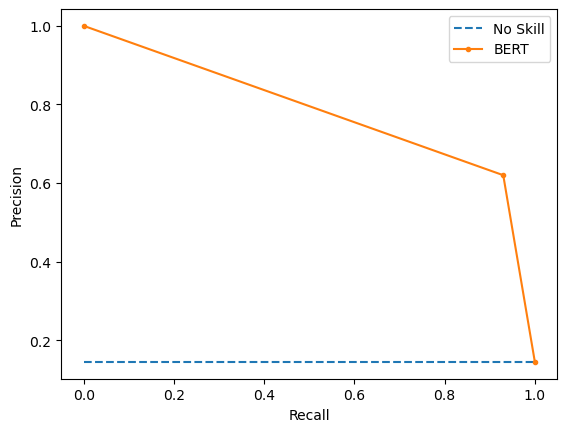

Test Loss: 0.138 | Test Acc: 90.659%
Epoch: 02 | Epoch Time: 1m 10s
	Train Loss: 0.144 | Train Acc: 90.82%
	 Val. Loss: 0.131 |  Val. Acc: 90.86%
test results for this epoch =  2
              precision    recall  f1-score   support

         0.0      0.986     0.914     0.949      2502
         1.0      0.664     0.930     0.775       458

    accuracy                          0.916      2960
   macro avg      0.825     0.922     0.862      2960
weighted avg      0.936     0.916     0.922      2960

[[2286  216]
 [  32  426]]
0.9162162162162162
Weighted_F1 0.9216243946700379
cohen_kappa_score 0.7248501458809983
lr_precision, lr_recall [0.15472973 0.6635514  1.        ] [1.       0.930131 0.      ]
Logistic: f1=0.775 auc=0.802
Length 458 2960
  no_skill  0.15472972972972973
                                  


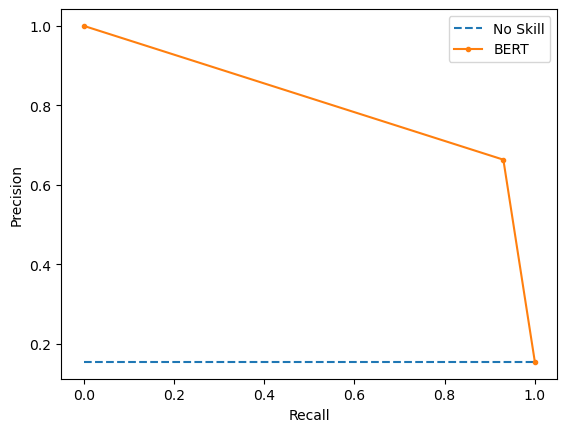

Test Loss: 0.131 | Test Acc: 91.599%
Epoch: 03 | Epoch Time: 1m 11s
	Train Loss: 0.121 | Train Acc: 92.35%
	 Val. Loss: 0.130 |  Val. Acc: 92.54%
test results for this epoch =  3
              precision    recall  f1-score   support

         0.0      0.966     0.950     0.958      2356
         1.0      0.818     0.869     0.843       604

    accuracy                          0.934      2960
   macro avg      0.892     0.910     0.900      2960
weighted avg      0.936     0.934     0.935      2960

[[2239  117]
 [  79  525]]
0.9337837837837838
Weighted_F1 0.9345243297559002
cohen_kappa_score 0.8008119139305314
lr_precision, lr_recall [0.20405405 0.81775701 1.        ] [1.        0.8692053 0.       ]
Logistic: f1=0.843 auc=0.857
Length 604 2960
  no_skill  0.20405405405405405
                                  


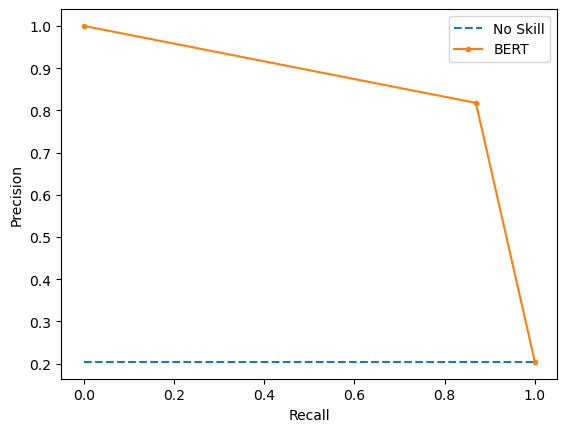

Test Loss: 0.132 | Test Acc: 93.347%
Epoch: 04 | Epoch Time: 1m 10s
	Train Loss: 0.095 | Train Acc: 94.14%
	 Val. Loss: 0.139 |  Val. Acc: 92.27%
test results for this epoch =  4
              precision    recall  f1-score   support

         0.0      0.972     0.937     0.954      2406
         1.0      0.763     0.884     0.819       554

    accuracy                          0.927      2960
   macro avg      0.868     0.911     0.887      2960
weighted avg      0.933     0.927     0.929      2960

[[2254  152]
 [  64  490]]
0.927027027027027
Weighted_F1 0.9290319709235145
cohen_kappa_score 0.7739838180105938
lr_precision, lr_recall [0.18716216 0.76323988 1.        ] [1.         0.88447653 0.        ]
Logistic: f1=0.819 auc=0.835
Length 554 2960
  no_skill  0.18716216216216217
                                  


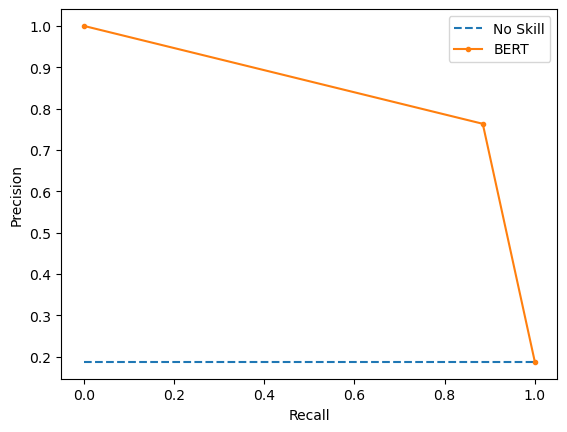

Test Loss: 0.137 | Test Acc: 92.675%
Epoch: 05 | Epoch Time: 1m 11s
	Train Loss: 0.072 | Train Acc: 95.75%
	 Val. Loss: 0.139 |  Val. Acc: 91.90%
test results for this epoch =  5
              precision    recall  f1-score   support

         0.0      0.973     0.937     0.954      2407
         1.0      0.763     0.886     0.820       553

    accuracy                          0.927      2960
   macro avg      0.868     0.911     0.887      2960
weighted avg      0.934     0.927     0.929      2960

[[2255  152]
 [  63  490]]
0.9273648648648649
Weighted_F1 0.9293856109546486
cohen_kappa_score 0.7748968218147759
lr_precision, lr_recall [0.18682432 0.76323988 1.        ] [1.         0.88607595 0.        ]
Logistic: f1=0.820 auc=0.835
Length 553 2960
  no_skill  0.18682432432432433
                                  


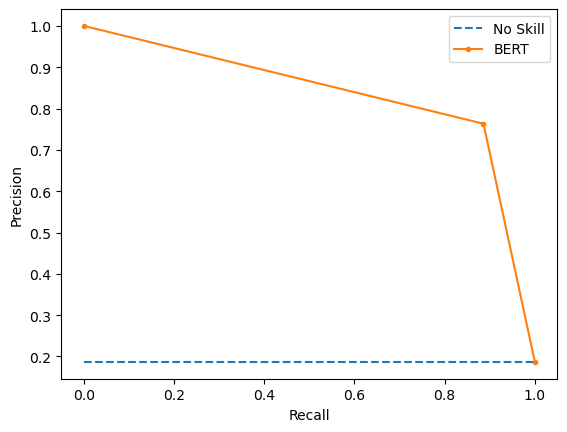

Test Loss: 0.143 | Test Acc: 92.708%
Epoch: 06 | Epoch Time: 1m 10s
	Train Loss: 0.040 | Train Acc: 97.67%
	 Val. Loss: 0.300 |  Val. Acc: 88.47%
test results for this epoch =  6
              precision    recall  f1-score   support

         0.0      0.991     0.883     0.934      2602
         1.0      0.525     0.941     0.674       358

    accuracy                          0.890      2960
   macro avg      0.758     0.912     0.804      2960
weighted avg      0.935     0.890     0.902      2960

[[2297  305]
 [  21  337]]
0.8898648648648648
Weighted_F1 0.9023253570643814
cohen_kappa_score 0.6140666344575592
lr_precision, lr_recall [0.12094595 0.52492212 1.        ] [1.         0.94134078 0.        ]
Logistic: f1=0.674 auc=0.737
Length 358 2960
  no_skill  0.12094594594594595
                                  


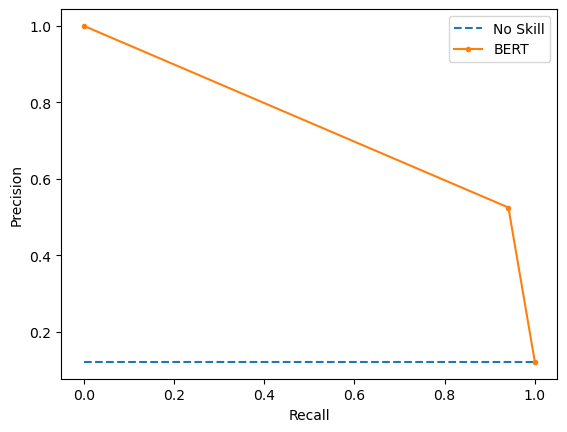

Test Loss: 0.296 | Test Acc: 88.911%
Epoch: 07 | Epoch Time: 1m 10s
	Train Loss: 0.028 | Train Acc: 98.45%
	 Val. Loss: 0.214 |  Val. Acc: 91.30%
test results for this epoch =  7
              precision    recall  f1-score   support

         0.0      0.971     0.930     0.950      2419
         1.0      0.737     0.874     0.800       541

    accuracy                          0.920      2960
   macro avg      0.854     0.902     0.875      2960
weighted avg      0.928     0.920     0.922      2960

[[2250  169]
 [  68  473]]
0.9199324324324324
Weighted_F1 0.9224967824726679
cohen_kappa_score 0.7500851431901836
lr_precision, lr_recall [0.18277027 0.73676012 1.        ] [1.         0.87430684 0.        ]
Logistic: f1=0.800 auc=0.817
Length 541 2960
  no_skill  0.18277027027027026
                                  


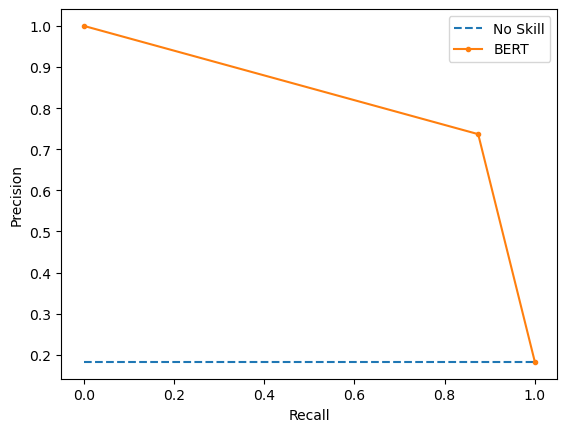

Test Loss: 0.205 | Test Acc: 91.902%
Epoch: 08 | Epoch Time: 1m 10s
	Train Loss: 0.022 | Train Acc: 98.80%
	 Val. Loss: 0.255 |  Val. Acc: 91.23%
test results for this epoch =  8
              precision    recall  f1-score   support

         0.0      0.953     0.946     0.950      2337
         1.0      0.802     0.827     0.814       623

    accuracy                          0.921      2960
   macro avg      0.878     0.886     0.882      2960
weighted avg      0.922     0.921     0.921      2960

[[2210  127]
 [ 108  515]]
0.9206081081081081
Weighted_F1 0.9210423075329908
cohen_kappa_score 0.7637603804829939
lr_precision, lr_recall [0.21047297 0.80218069 1.        ] [1.         0.82664526 0.        ]
Logistic: f1=0.814 auc=0.833
Length 623 2960
  no_skill  0.21047297297297296
                                  


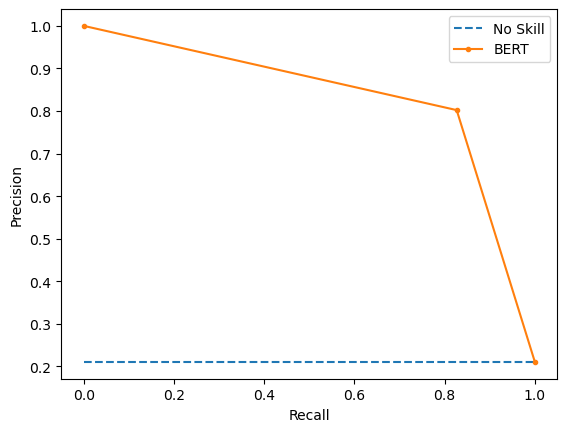

Test Loss: 0.250 | Test Acc: 92.070%
Epoch: 09 | Epoch Time: 1m 11s
	Train Loss: 0.022 | Train Acc: 98.77%
	 Val. Loss: 0.327 |  Val. Acc: 91.43%
test results for this epoch =  9
              precision    recall  f1-score   support

         0.0      0.929     0.956     0.942      2251
         1.0      0.847     0.767     0.805       709

    accuracy                          0.911      2960
   macro avg      0.888     0.862     0.874      2960
weighted avg      0.909     0.911     0.910      2960

[[2153   98]
 [ 165  544]]
0.9111486486486486
Weighted_F1 0.9095969107144045
cohen_kappa_score 0.7479508541723057
lr_precision, lr_recall [0.23952703 0.84735202 1.        ] [1.         0.76727786 0.        ]
Logistic: f1=0.805 auc=0.835
Length 709 2960
  no_skill  0.23952702702702702
                                  


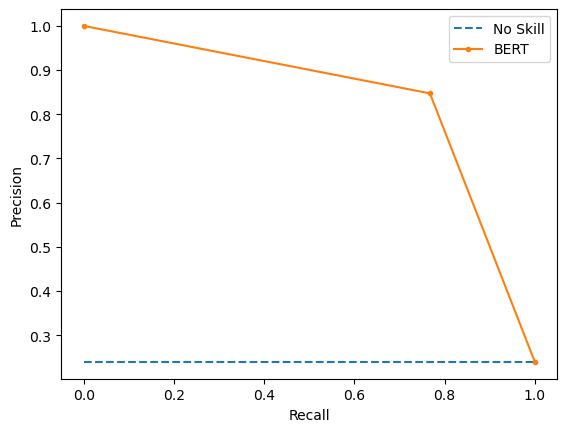

Test Loss: 0.331 | Test Acc: 91.129%
Epoch: 10 | Epoch Time: 1m 10s
	Train Loss: 0.014 | Train Acc: 99.30%
	 Val. Loss: 0.325 |  Val. Acc: 90.29%
test results for this epoch =  10
              precision    recall  f1-score   support

         0.0      0.981     0.918     0.949      2476
         1.0      0.685     0.909     0.782       484

    accuracy                          0.917      2960
   macro avg      0.833     0.914     0.865      2960
weighted avg      0.933     0.917     0.921      2960

[[2274  202]
 [  44  440]]
0.9168918918918919
Weighted_F1 0.9213532120854107
cohen_kappa_score 0.7314553104107535
lr_precision, lr_recall [0.16351351 0.68535826 1.        ] [1.         0.90909091 0.        ]
Logistic: f1=0.782 auc=0.805
Length 484 2960
  no_skill  0.1635135135135135
                                  


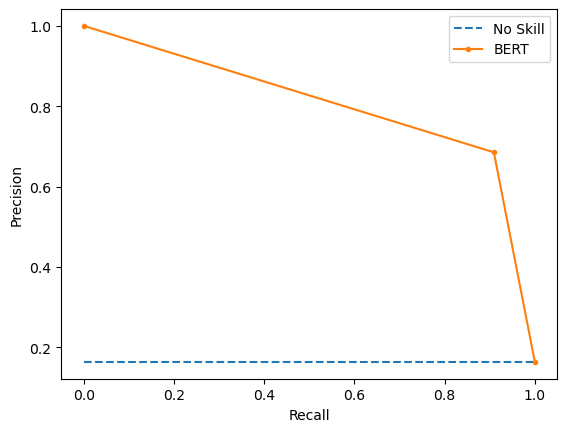

Test Loss: 0.308 | Test Acc: 91.633%
Best epoch=  3


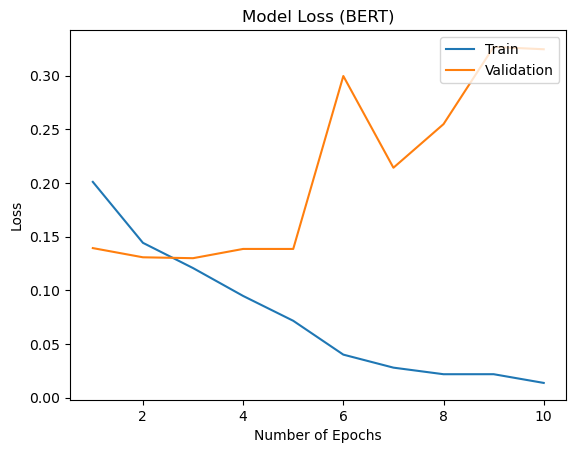

In [36]:
import matplotlib.pyplot as plt

def my_plot(epochs, loss):
    plt.plot(epochs, loss)
    plt.title('Model Loss (BERT)')
    plt.ylabel('Loss')
    plt.xlabel('Number of Epochs')
    plt.legend(["Train",'Validation'],loc='upper right')

def my_plotACC(epochs, acc):
    plt.plot(epochs, acc)
    plt.title('Model accuracy (BERT)')
    plt.ylabel('Accuracy')
    plt.xlabel('Number of Epochs')
    plt.legend(["Train",'Validation'],loc='upper left')
N_EPOCHS = n_epoch_number

best_valid_loss = float('inf')
best_valid_acc = float('-inf')
train_loss_vals=  []
valid_loss_vals=  []

train_acc_vals=  []
valid_accs_vals=  []

for epoch in range(N_EPOCHS):
    #if (epoch > 0) and (epoch % 10 == 0):
           #reduce_lr()
            
    start_time = time.time()
    
    train_loss, train_acc = train(model, train_iterator, optimizer, criterion)
    valid_loss, valid_acc,_,_  = evaluate(model, valid_iterator, criterion)

    train_loss_vals.append(train_loss)
    valid_loss_vals.append(valid_loss)
    train_acc_vals.append(train_acc)
    valid_accs_vals.append(valid_acc)    
    end_time = time.time()
        
    epoch_mins, epoch_secs = epoch_time(start_time, end_time)
        
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
#         torch.save(model.state_dict(), 'tut6-model.pt')  
        torch.save(model.state_dict(), model_file_name)
        best_epoch = epoch+1

    '''if valid_acc > best_valid_acc:
        best_valid_acc = valid_acc
        torch.save(model.state_dict(), 'tut6-model.pt')
        best_epoch = epoch+1 '''

    print(f'Epoch: {epoch+1:02} | Epoch Time: {epoch_mins}m {epoch_secs}s')
    print(f'\tTrain Loss: {train_loss:.3f} | Train Acc: {train_acc*100:.2f}%')
    print(f'\t Val. Loss: {valid_loss:.3f} |  Val. Acc: {valid_acc*100:.2f}%')
    
    #     new lines i addes to monitor test results 
    print ('test results for this epoch = ', epoch+1)
    test_loss, test_acc, y_true,y_pred = evaluate(model, test_iterator, criterion)
    print(classification_report(y_true, y_pred,digits = 3))
    print(confusion_matrix(y_true, y_pred))
    print(accuracy_score(y_true, y_pred))
    print('Weighted_F1',f1_score(y_true, y_pred, average='weighted'))
    print('cohen_kappa_score',cohen_kappa_score(y_true, y_pred))

    lr_precision, lr_recall, _ = precision_recall_curve(y_true,y_pred)
    print('lr_precision, lr_recall',lr_precision, lr_recall)
    lr_f1, lr_auc = f1_score(y_true,y_pred), auc(lr_recall, lr_precision)

    print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
    # plot the precision-recall curves
    ones = [x for x in y_true if x==1]
    print('Length',len(ones),len(y_true))
    no_skill = len(ones) / len(y_true)
    print('  no_skill ', no_skill)
    print('                                  ')
    plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
    plt.plot(lr_recall, lr_precision, marker='.', label='BERT')
    # axis labels
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    # show the legend
    plt.legend()
    # show the plot
    plt.show()
# end of update
    print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.3f}%')

print('Best epoch= ',best_epoch)
#my_plotACC(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), train_acc_vals)
#my_plotACC(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), valid_accs_vals)
my_plot(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), train_loss_vals)
my_plot(np.linspace(1, N_EPOCHS, N_EPOCHS).astype(int), valid_loss_vals)  

Test Loss: 0.132 | Test Acc: 93.347%
              precision    recall  f1-score   support

         0.0      0.966     0.950     0.958      2356
         1.0      0.818     0.869     0.843       604

    accuracy                          0.934      2960
   macro avg      0.892     0.910     0.900      2960
weighted avg      0.936     0.934     0.935      2960

[[2239  117]
 [  79  525]]
0.9337837837837838
Weighted_F1 0.9345243297559002
cohen_kappa_score 0.8008119139305314
lr_precision, lr_recall [0.20405405 0.81775701 1.        ] [1.        0.8692053 0.       ]
Logistic: f1=0.843 auc=0.857
Length 604 2960
  no_skill  0.20405405405405405
                                  


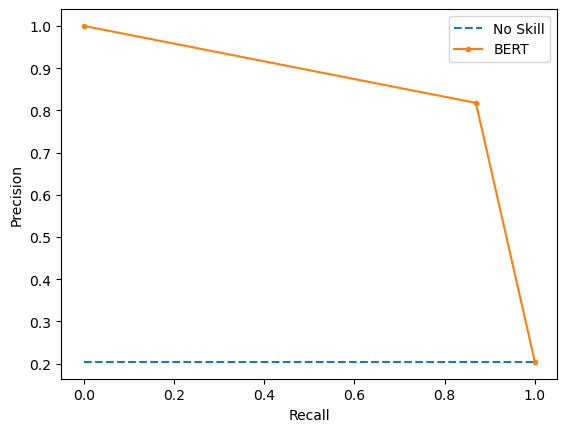

In [37]:
from sklearn.metrics import classification_report
from sklearn.metrics import f1_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import auc
from sklearn.metrics import cohen_kappa_score

model.load_state_dict(torch.load(model_file_name))
test_loss, test_acc, y_true,y_pred = evaluate(model, test_iterator, criterion)

print(f'Test Loss: {test_loss:.3f} | Test Acc: {test_acc*100:.3f}%')
print(classification_report(y_true, y_pred,digits = 3))

print(confusion_matrix(y_true, y_pred))
print(accuracy_score(y_true, y_pred))
print('Weighted_F1',f1_score(y_true, y_pred, average='weighted'))
print('cohen_kappa_score',cohen_kappa_score(y_true, y_pred))

lr_precision, lr_recall, _ = precision_recall_curve(y_true,y_pred)
print('lr_precision, lr_recall',lr_precision, lr_recall)
lr_f1, lr_auc = f1_score(y_true,y_pred), auc(lr_recall, lr_precision)

print('Logistic: f1=%.3f auc=%.3f' % (lr_f1, lr_auc))
# plot the precision-recall curves
ones = [x for x in y_true if x==1]
print('Length',len(ones),len(y_true))
no_skill = len(ones) / len(y_true)
print('  no_skill ', no_skill)
print('                                  ')
plt.plot([0, 1], [no_skill, no_skill], linestyle='--', label='No Skill')
plt.plot(lr_recall, lr_precision, marker='.', label='BERT')
# axis labels
plt.xlabel('Recall')
plt.ylabel('Precision')
# show the legend
plt.legend()
# show the plot
plt.show()
